In [1]:
import os
import sys
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

In [62]:
mech_yaml = '/scratch/harris.se/guassian_scratch/fresh_autoscience/RMG_min_6/chem_annotated.yaml'
mech_yaml = '/projects/westgroup/harris.se/autoscience/fuels/butane/fresh_autoscience/RMG_min/butane_20251207/chem_annotated.yaml'



gas = ct.Solution(mech_yaml)
print(f'{gas.n_species} species')
print(f'{gas.n_reactions} reactions')

294 species
6471 reactions


In [78]:
base_delays = np.load('/scratch/harris.se/guassian_scratch/fresh_autoscience/RMG_min_6/table_0007/base_delays_0007.npy')
Ar_delays = np.load('/scratch/harris.se/guassian_scratch/fresh_autoscience/RMG_min_6/table_0007/spec_delay_0007_0000.npy')

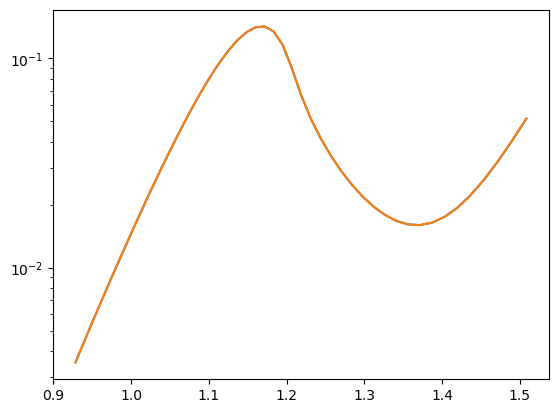

In [79]:
plt.plot(1000.0 / np.linspace(663, 1077, 51), base_delays)
plt.plot(1000.0 / np.linspace(663, 1077, 51), Ar_delays)
plt.yscale('log')

In [80]:
T_init = 787
P_init = 10 * ct.one_atm
# X_init = 'butane(1): 0.032065, N2: 0.7821, O2(2): 0.02083'
X_init = 'butane(1): 0.03135, N2: 0.7649, O2(2): 0.2038'
    
gas.TPX = T_init, P_init, X_init
reactor = ct.IdealGasReactor(gas)
sim = ct.ReactorNet([reactor])
    
t_end = 10.0  # seconds
times = []
concentrations = []
rates = []
Ps = []
while sim.time < t_end:
    sim.step()
    times.append(sim.time)
    concentrations.append(gas.X)
    rates.append(gas.net_rates_of_progress)
    Ps.append(gas.P)
    
times = np.array(times)
concentrations = np.array(concentrations)
rates = np.array(rates)
Ps = np.array(Ps)
    
np.save(os.path.join(os.path.dirname(mech_yaml), 'times.npy'), times)
np.save(os.path.join(os.path.dirname(mech_yaml), 'concentrations.npy'), concentrations)
np.save(os.path.join(os.path.dirname(mech_yaml), 'rates.npy'), rates)
np.save(os.path.join(os.path.dirname(mech_yaml), 'Ps.npy'), Ps)



/tmp/ipykernel_2368976/267997615.py:7: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasReactor(gas)


In [81]:
def get_i_thing(ref_composition, phase):
	for i in range(phase.n_species):
		if phase.species()[i].composition == ref_composition:
			return i
	return -1

In [82]:
i_OH = get_i_thing({'O': 1, 'H': 1}, gas)

Text(0, 0.5, 'OH concentration')

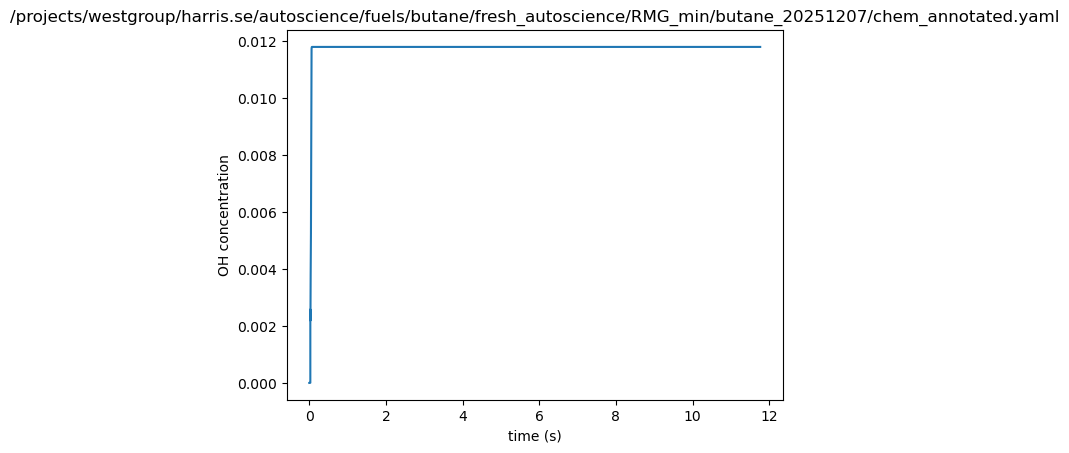

In [83]:
plt.plot(times, concentrations[:, i_OH])
plt.xlabel('time (s)')
plt.title(mech_yaml)
plt.ylabel('OH concentration')

In [84]:
END_1s = int(np.argmin(np.abs(times - 1.0)))

slopes = np.gradient(Ps, times)
delay_i = np.argmax(slopes)
delay = times[delay_i]
print(delay)

slopes = np.gradient(Ps[:END_1s], times[:END_1s])
delay_i = np.argmax(slopes)
delay = times[delay_i]
print(delay)

0.02700841859582066
0.02700841859582066


0.02700841859582066


Text(0, 0.5, 'P')

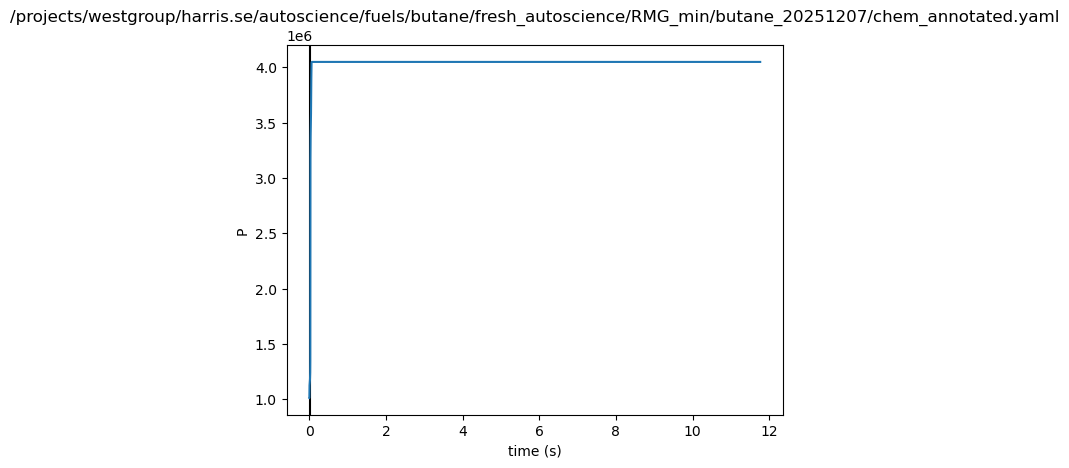

In [85]:
slopes = np.gradient(Ps, times)
delay_i = np.argmax(slopes)
delay = times[delay_i]
print(delay)

plt.axvline(x=delay, color='black', label='delay')

plt.plot(times, Ps)
plt.xlabel('time (s)')
plt.title(mech_yaml)
plt.ylabel('P')